In [1]:
import sys
sys.path.insert(1, '/home/bricej/MyPythonLibrary/StageM2_IVT/library/')
import domain
from domain import *
from climbas import *
import numpy as np
import xarray as xr
import pandas as pd
from netCDF4 import Dataset
from scipy import stats
import scipy.stats as stats
import matplotlib.pyplot as plt

# Period

In [2]:
iyear = 1981
fyear = 2015
models = ['APHRO','CHIRPS','CRU','ERA5','GPCP','HARv2']
domains = ['HMA','HK','SL','TP','CH','SEH']

# TP DATASETS

In [3]:
tp_datasets = {}

files = {
    'APHRO': 'tp_HMA_1951-2015_APHRO.nc',
    'GPCP': 'tp_HMA_1891-2019_GPCP.nc',
    'CRU': 'tp_HMA_1901-2020_CRU.nc',
    'CHIRPS': 'tp_HMA_1981-2025_CHIRPS.nc',
    'HARv2': 'tp_HMA_1980-2023_HARv2.nc',
    'ERA5': 'tp_HMA_1940-2025_ERA5.nc'
}

path = '/bettik/PROJECTS/pr-regional-climate/bricej/tp_datasets/'

def xy_sel_dom(ds,latS,latN,lonW,lonE):
    #latS,latN,lonW,lonE=coord_domain(domain)
    lat_str = ''
    lon_str = ''
    other_dims_str = []
    for dim in ds.coords:
        if dim in ['lat', 'latitude','LON']:
            lat_str = dim
        elif dim in ['lon', 'longitude','LAT']:
            lon_str = dim
        else:
            other_dims_str.append(dim)
    mask = (
        (latS < ds[lat_str]) & ( ds[lat_str] < latN) 
    & (lonW < ds[lon_str]) & ( ds[lon_str] < lonE)
    )
    field_dom=ds.where(mask,drop=True)
    return field_dom

for model in models:
    tp_datasets[model] = {}
    tp_model = xr.open_dataset(path + files[model])['tp']
    tp_model=tp_model.sel(time=slice(str(iyear),str(fyear)))
    for domain in domains:
        if model == 'HARv2':
            latS,latN,lonW,lonE = coord_domain(domain)
            tp_datasets[model][domain]=xy_sel_dom(tp_model,latS,latN,lonW,lonE)
        else:
            tp_datasets[model][domain] = field_dom(tp_model,domain)

# MONTHLY MEAN DATASETS DOMAINS

In [4]:
tp_mean_dict = {}

for model in models:
    tp_mean_dict[model]={}
    print(model)
    for domain in domains:
        tp_mean_dict[model][domain] = tp_datasets[model][domain].groupby('time.month').mean('time', skipna=True)
        if model == 'HARv2':
            tp_mean_dict[model][domain] = tp_mean_dict[model][domain].mean(dim=['south_north','west_east'], skipna=True)
        else:
            tp_mean_dict[model][domain] = tp_mean_dict[model][domain].mean(dim=['lat','lon'], skipna=True)
        print(domain)


APHRO
HMA
HK
SL
TP
CH
SEH
CHIRPS
HMA
HK
SL
TP
CH
SEH
CRU
HMA
HK
SL
TP
CH
SEH
ERA5
HMA
HK
SL
TP
CH
SEH
GPCP
HMA
HK
SL
TP
CH
SEH
HARv2
HMA
HK
SL
TP
CH
SEH


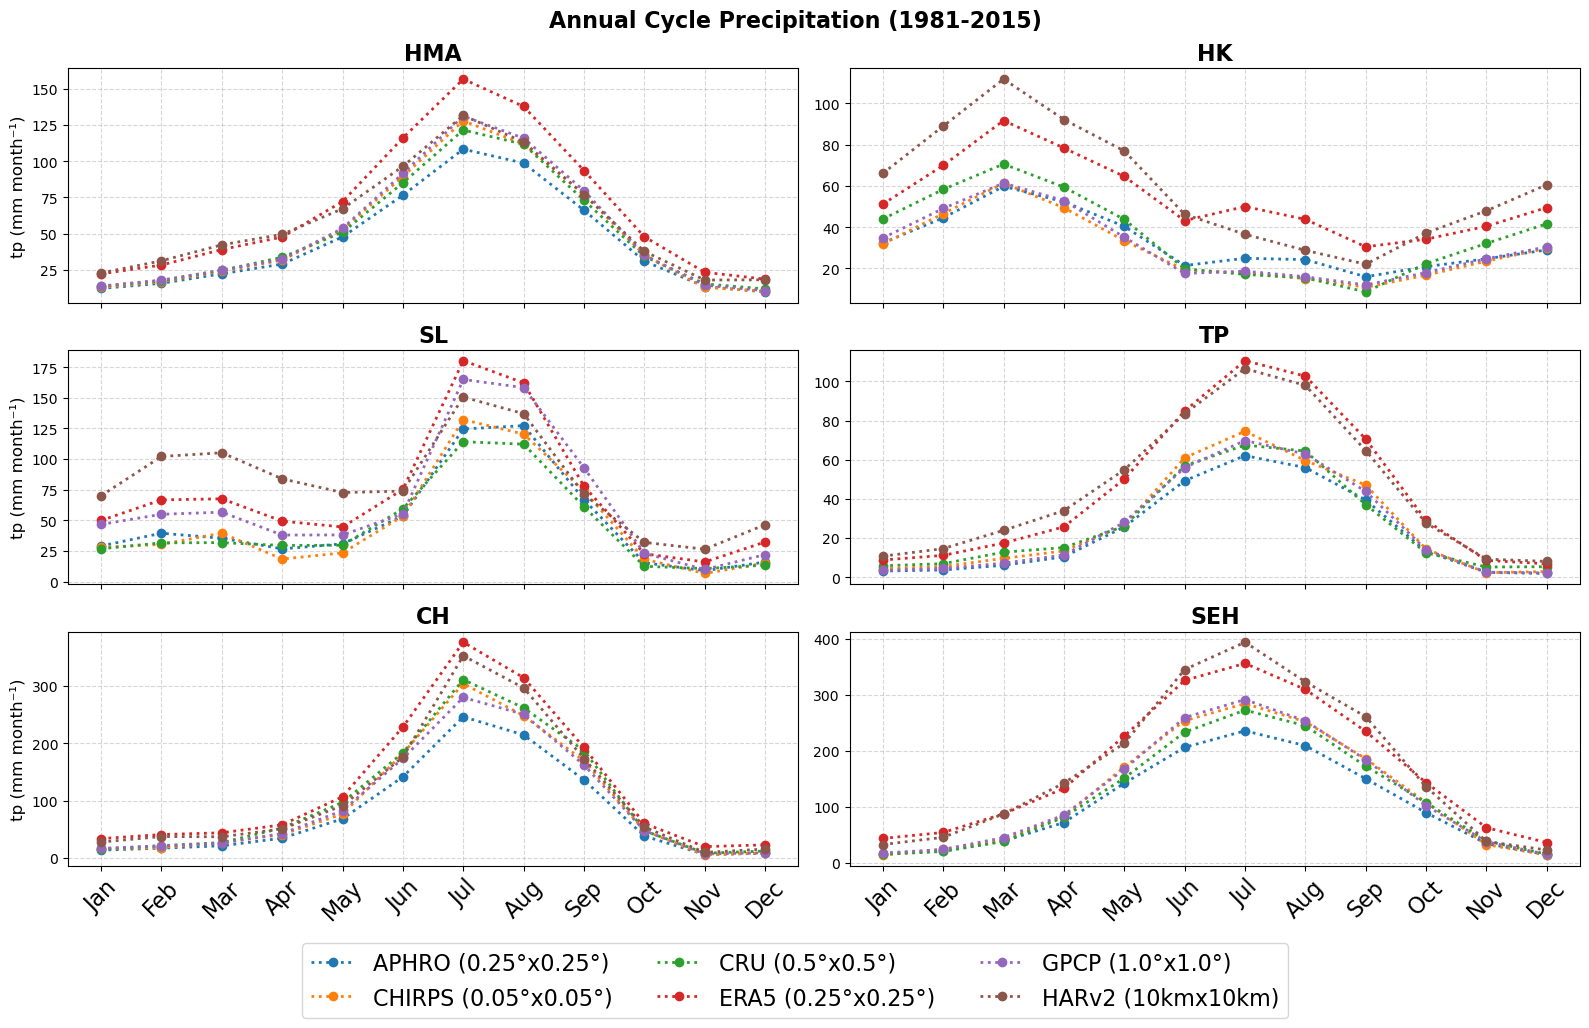

In [5]:
months = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
resolutions = {'APHRO': '0.25°x0.25°',
               'GPCP': '1.0°x1.0°',
               'CRU': '0.5°x0.5°',
               'CHIRPS': '0.05°x0.05°',
               'HARv2': '10kmx10km',
               'ERA5': '0.25°x0.25°'}
colors = {'APHRO': 'orange', 
          'GPCP': 'pink', 
          'CRU': 'red', 
          'CHIRPS': 'green',
          'HARv2': 'black',
          'ERA5': 'brown'}

fig, axes = plt.subplots(3, 2, figsize=(16,10))
axes = axes.flatten()

for i, dom in enumerate(domains):

    ax = axes[i]

    for model in models:
        da = tp_mean_dict[model][dom]
        ax.plot(da['month'], da.values, marker='o', linestyle=':', label=f'{model} ({resolutions[model]})', linewidth=2)

    ax.set_title(dom, fontsize=16, weight="bold")
    ax.set_xticks(range(1,13))
    
    if i in [0, 2, 4]:  # colonne gauche
        ax.set_ylabel('tp (mm month⁻¹)', fontsize=12)
    if i in [4, 5]:  # ligne du bas
        ax.set_xticklabels(months, rotation=45, fontsize=16)
    if i in [0,1,2,3]:
        ax.tick_params(labelbottom=False)
    
    ax.grid(True, linestyle='--', alpha=0.5)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc='lower center',
    bbox_to_anchor=(0.5, -0.04),
    ncol=3,
    fontsize=16,
    frameon=True
)
fig.suptitle(f'Annual Cycle Precipitation ({iyear}-{fyear})', fontsize=16, weight='bold')

plt.tight_layout(rect=[0,0.05,1,1])
plt.show()

# For oral presentation

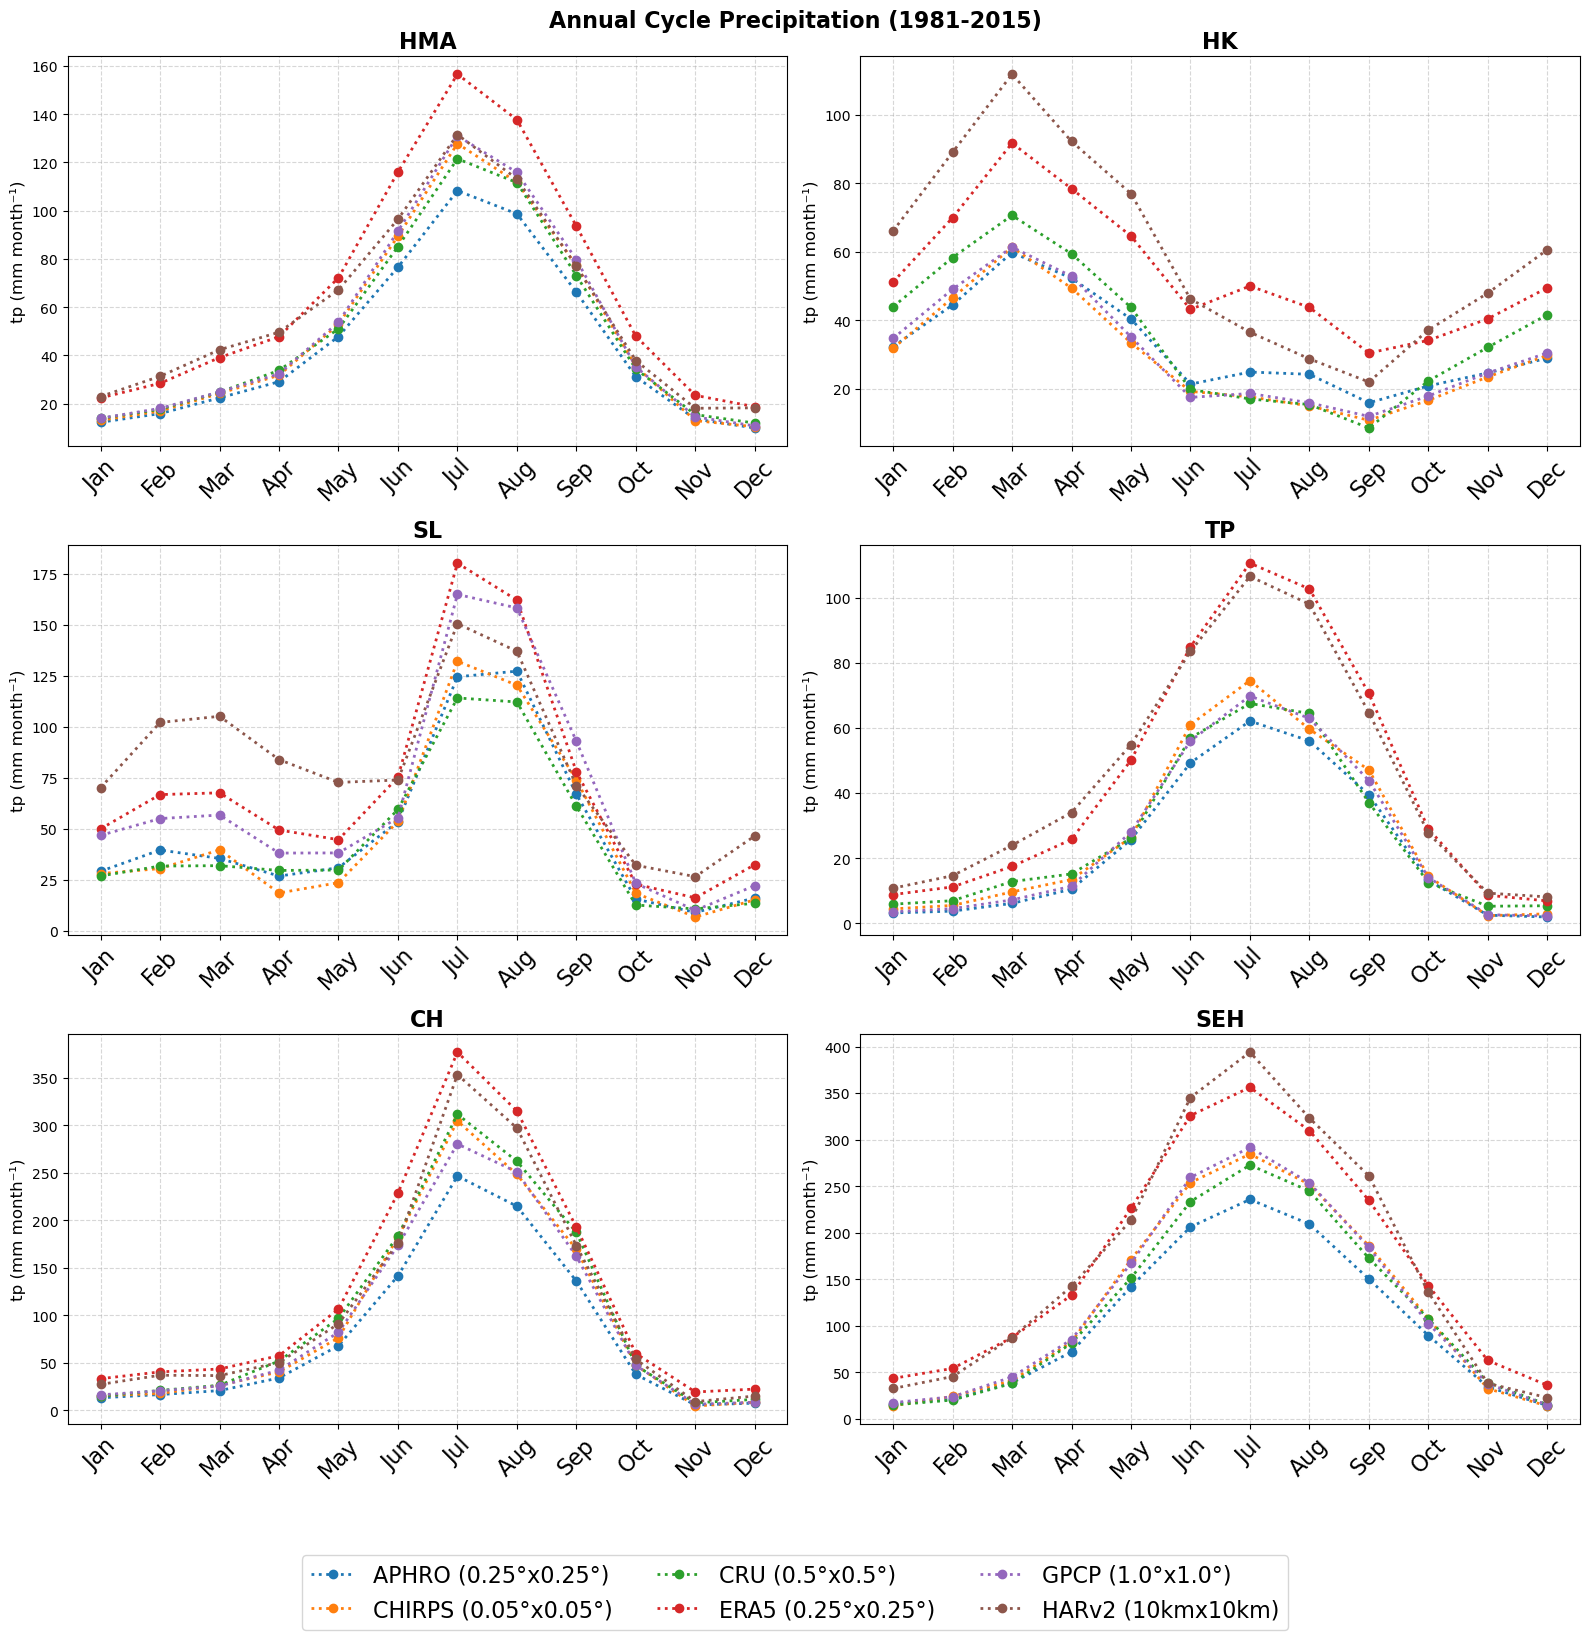

In [9]:
months = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
resolutions = {'APHRO': '0.25°x0.25°',
               'GPCP': '1.0°x1.0°',
               'CRU': '0.5°x0.5°',
               'CHIRPS': '0.05°x0.05°',
               'HARv2': '10kmx10km',
               'ERA5': '0.25°x0.25°'}
colors = {'APHRO': 'orange', 
          'GPCP': 'pink', 
          'CRU': 'red', 
          'CHIRPS': 'green',
          'HARv2': 'black',
          'ERA5': 'brown'}

fig, axes = plt.subplots(3, 2, figsize=(16,16))
axes = axes.flatten()

for i, dom in enumerate(domains):

    ax = axes[i]

    for model in models:
        da = tp_mean_dict[model][dom]
        ax.plot(da['month'], da.values, marker='o', linestyle=':', label=f'{model} ({resolutions[model]})', linewidth=2)

    ax.set_title(dom, fontsize=16, weight="bold")
    ax.set_xticks(range(1,13))
    ax.set_xticklabels(months, rotation=45, fontsize=16)
    ax.set_ylabel('tp (mm month⁻¹)', fontsize=12)
    
    ax.grid(True, linestyle='--', alpha=0.5)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc='lower center',
    bbox_to_anchor=(0.5, -0.04),
    ncol=3,
    fontsize=16,
    frameon=True
)
fig.suptitle(f'Annual Cycle Precipitation ({iyear}-{fyear})', fontsize=16, weight='bold')

plt.tight_layout(rect=[0,0.05,1,1])
plt.show()

# Only ERA5

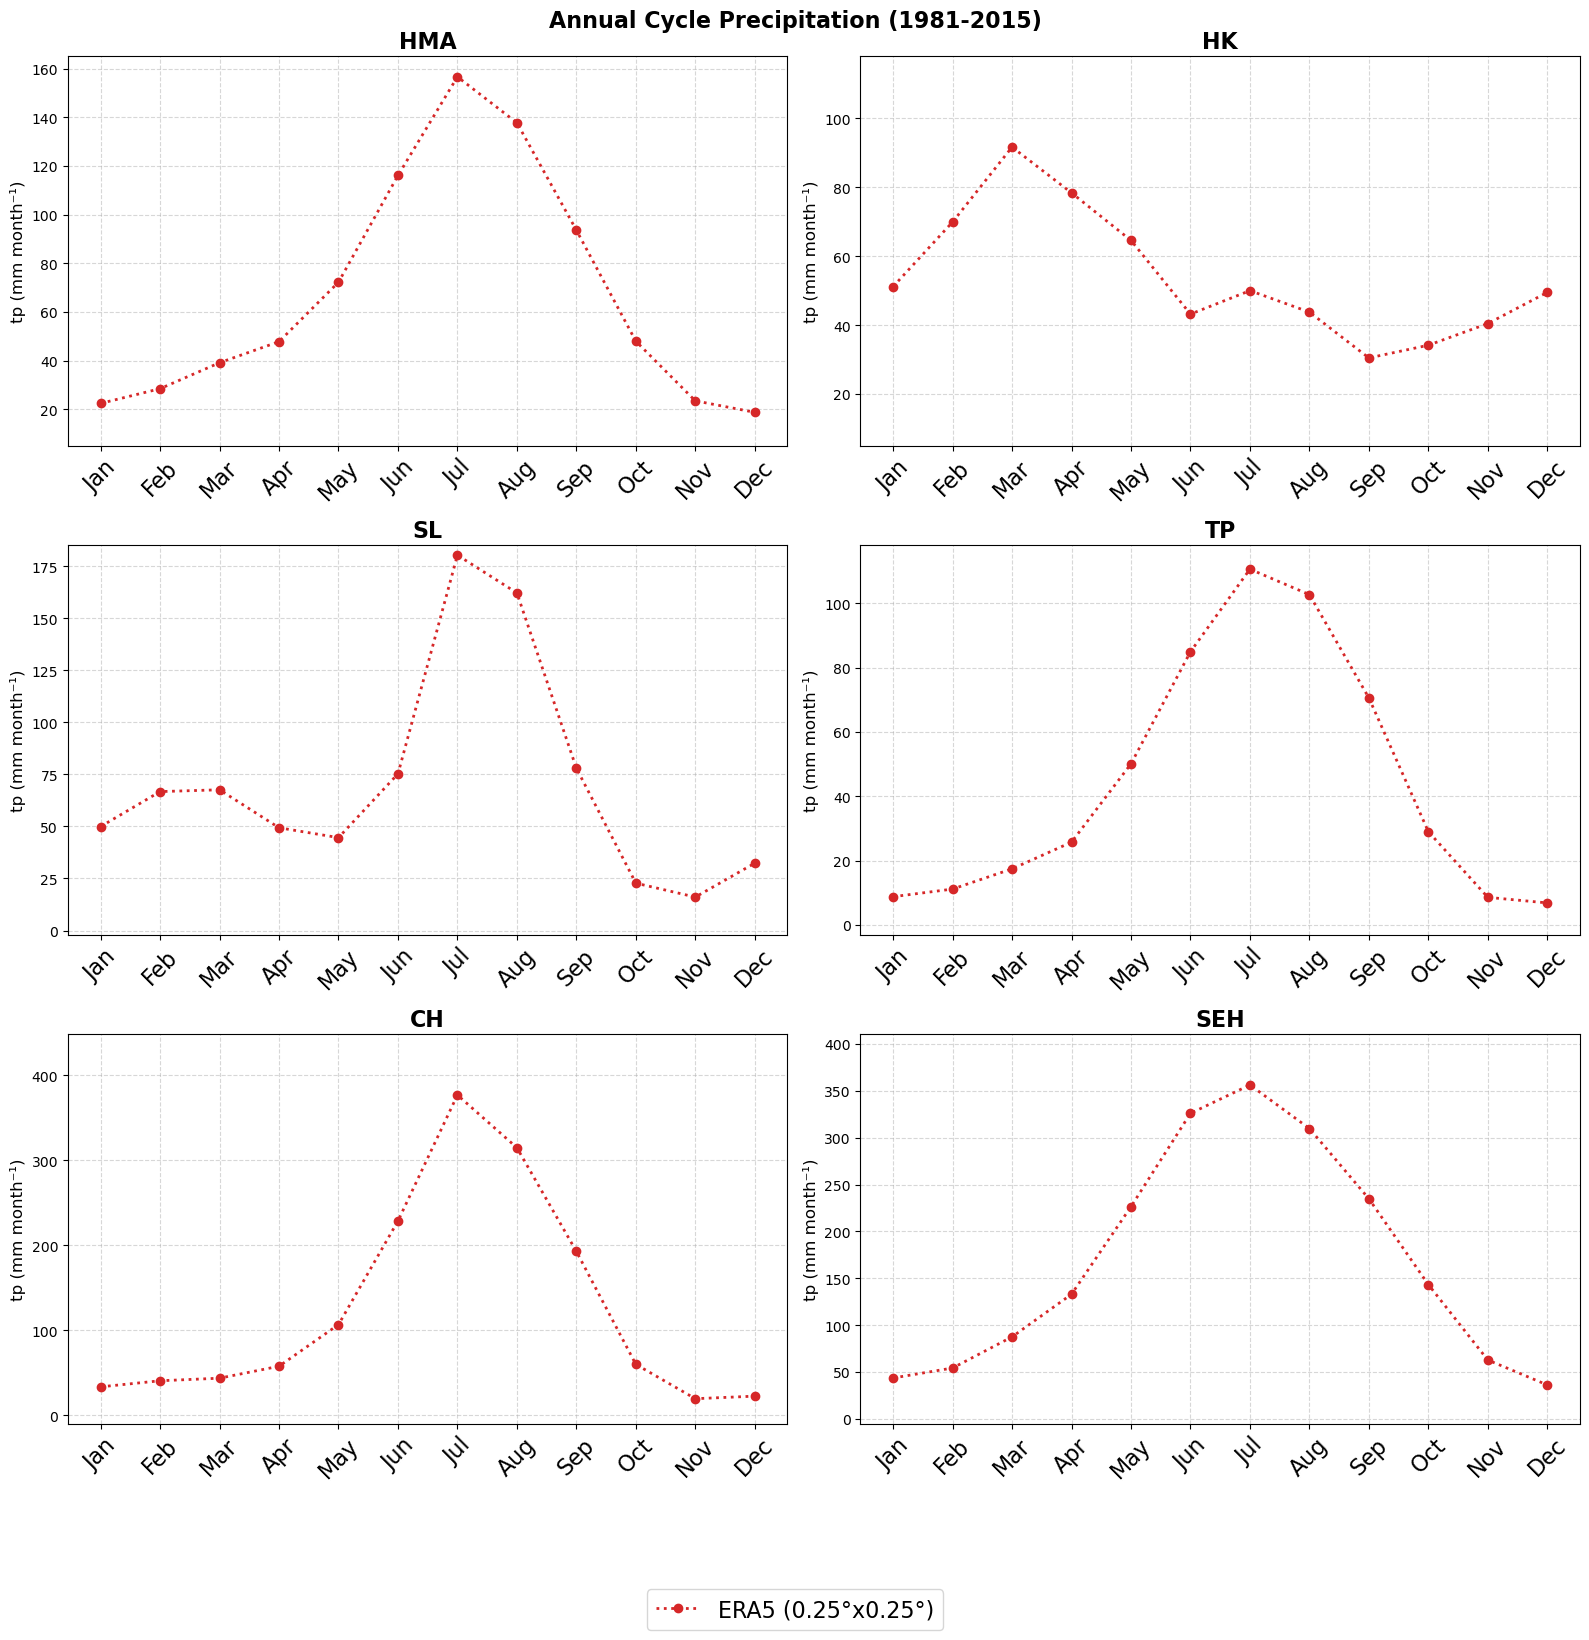

In [11]:
months = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
resolutions = {'APHRO': '0.25°x0.25°',
               'GPCP': '1.0°x1.0°',
               'CRU': '0.5°x0.5°',
               'CHIRPS': '0.05°x0.05°',
               'HARv2': '10kmx10km',
               'ERA5': '0.25°x0.25°'}
colors = {'APHRO': 'orange', 
          'GPCP': 'pink', 
          'CRU': 'red', 
          'CHIRPS': 'green',
          'HARv2': 'black',
          'ERA5': 'brown'}

ylimits = {'HMA' : [5,165],
          'HK' : [5,118],
          'SL' : [-2,185],
          'TP' : [-3,118],
          'CH' : [-10,448],
          'SEH' : [-5,410]}

fig, axes = plt.subplots(3, 2, figsize=(16,16))
axes = axes.flatten()

for i, dom in enumerate(domains):

    ax = axes[i]

    for model in ['ERA5']:
        da = tp_mean_dict[model][dom]
        ax.plot(da['month'], da.values, marker='o', linestyle=':', label=f'{model} ({resolutions[model]})', linewidth=2, color='tab:red')

    ax.set_title(dom, fontsize=16, weight="bold")
    ax.set_xticks(range(1,13))
    ax.set_xticklabels(months, rotation=45, fontsize=16)
    ax.set_ylabel('tp (mm month⁻¹)', fontsize=12)

    ax.set_ylim(ylimits[dom])
    
    ax.grid(True, linestyle='--', alpha=0.5)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc='lower center',
    bbox_to_anchor=(0.5, -0.04),
    ncol=3,
    fontsize=16,
    frameon=True
)
fig.suptitle(f'Annual Cycle Precipitation ({iyear}-{fyear})', fontsize=16, weight='bold')

plt.tight_layout(rect=[0,0.05,1,1])
plt.show()